# 00 — Data Preparation

Loads, preprocesses, and saves all features to `data/prepared/` so Task 1 and Task 2 notebooks can run independently without re-processing the dataset.

## 1. Imports

The standard scientific Python stack is imported here. `numpy` and `pandas` handle array and tabular operations respectively. `matplotlib` and `seaborn` are used for visualisation of feature distributions and importance rankings. `scikit-learn` provides the preprocessing utilities (`StandardScaler`, `train_test_split`) and the preliminary `RandomForestClassifier` and `RandomForestRegressor` used solely for feature importance ranking. `joblib` serialises the fitted scalers to disk, ensuring that `01_Classification.ipynb` and `02_Regression.ipynb` apply the exact same scaling transformation — fitted only on training data — without re-running any preprocessing. `RANDOM_STATE = 42` is set globally to ensure reproducibility across all stochastic operations.

In [1]:
from pathlib import Path; Path("results/data_prep").mkdir(parents=True, exist_ok=True)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from scipy.stats import kurtosis, skew
import joblib, json

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 40)

RANDOM_STATE = 42
print("Imports loaded.")

Imports loaded.


## 2. Data Loading

We load from the pre-exported CSV produced by the EDA notebook (`data/uwb_preprocessed_for_ml.csv`). This file already contains the raw metadata features plus 8 RXPACC-normalised CIR statistical features pre-computed by the EDA pipeline — no re-processing of raw CSVs is needed here.

In [2]:
df_raw = pd.read_csv(Path("data") / "uwb_preprocessed_for_ml.csv")

display(pd.DataFrame({
    'Metric': ['Total rows', 'Total columns', 'LOS samples (NLOS=0)', 'NLOS samples (NLOS=1)', 'Class balance'],
    'Value': [
        f"{df_raw.shape[0]:,}",
        df_raw.shape[1],
        f"{(df_raw['NLOS']==0).sum():,}",
        f"{(df_raw['NLOS']==1).sum():,}",
        '50/50 '
    ]
}))

,Metric,Value
0,Total rows,"42,000"
1,Total columns,1036
2,LOS samples (NLOS=0),"21,000"
3,NLOS samples (NLOS=1),"21,000"
4,Class balance,50/50


## 3. Data Preprocessing

### Feature Scaling

`FP_AMP1` values can reach ~20,000 while `FP_IDX` stays around 700–850. Distance-based and gradient models (SVM, Logistic Regression, MLP, CNN) are sensitive to this scale difference, so we apply `StandardScaler` to normalise all features to zero mean and unit variance. Tree-based models (RF, XGBoost) do not strictly need this, but it does not hurt them.

### Train/Test Split — 80:20

We use a stratified 80:20 split: 33,600 training samples and 8,400 test samples. Stratification keeps the 50:50 LOS/NLOS balance in both sets.

In [3]:
RANDOM_STATE = 42

# ── Column definitions ────────────────────────────────────────────────────────
TARGET_CLASS = 'NLOS'
TARGET_REG   = 'RANGE'

METADATA_FEATURES = [
    'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
    'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'FRAME_LEN', 'PREAM_LEN'
]

CIR_COLS = sorted(
    [c for c in df_raw.columns if c.startswith('CIR') and c[3:].isdigit()],
    key=lambda x: int(x[3:])
)

CIR_STATS_COLS = [
    'cir_mean', 'cir_std', 'cir_max', 'cir_peak_idx',
    'cir_energy', 'cir_kurtosis', 'cir_skewness', 'cir_rms'
]

# CIR waveform matrix and pre-computed stats (from EDA output)
cir_matrix = df_raw[CIR_COLS].values.astype(np.float32)
cir_stats  = df_raw[CIR_STATS_COLS]

FEATURE_NAMES     = METADATA_FEATURES + CIR_STATS_COLS
REG_FEATURE_NAMES = [f for f in FEATURE_NAMES if f != TARGET_REG]

print(f"Metadata features : {len(METADATA_FEATURES)}")
print(f"CIR raw columns   : {len(CIR_COLS)}")
print(f"CIR stat features : {len(CIR_STATS_COLS)}")
print(f"Total clf features: {len(FEATURE_NAMES)}")

Metadata features : 11
CIR raw columns   : 1016
CIR stat features : 8
Total clf features: 19


In [4]:
# CIR statistical features are pre-computed by the EDA notebook (RXPACC-normalised).
# Verify they are present and well-formed in the loaded DataFrame.
print("CIR statistical features (loaded from EDA output):")
display(df_raw[CIR_STATS_COLS].describe().round(4))

CIR statistical features (loaded from EDA output):


,cir_mean,cir_std,cir_max,cir_peak_idx,cir_energy,cir_kurtosis,cir_skewness,cir_rms
count,42000.0000,42000.0000,42000.0000,42000.0000,42000.0000,42000.0000,42000.0000,42000.0000
mean,0.8499,2.3825,36.2952,750.8763,8589.3388,111.5764,9.5158,2.5375
std,0.3900,1.3796,22.5948,5.1505,7615.9514,48.4045,2.2209,1.4196
min,0.2887,0.2574,2.6062,716.0000,164.0471,-1.1488,-0.4871,0.4018
25%,0.4645,0.9883,13.6804,748.0000,1233.7841,73.3172,7.8494,1.1020
50%,0.8138,2.3661,35.1647,750.0000,6361.2368,106.6917,9.5021,2.5022
75%,1.2038,3.6783,57.1029,753.0000,15291.0460,145.0215,11.1939,3.8795
max,1.8958,5.0846,86.7903,950.0000,28176.9060,326.5890,16.7402,5.2662


In [5]:
# ── Build combined feature matrix ─────────────────────────────────────────────
# Features for classification (RANGE included — it is a signal measurement, not the target here)
X_meta   = df_raw[METADATA_FEATURES].values
X_cir_s  = cir_stats.values
X_all    = np.hstack([X_meta, X_cir_s])             # shape: (42000, 19)

# Features for regression (exclude RANGE — it IS the target)
META_NO_RANGE = [f for f in METADATA_FEATURES if f != 'RANGE']
X_reg    = np.hstack([df_raw[META_NO_RANGE].values, X_cir_s])  # shape: (42000, 18)

y_class  = df_raw[TARGET_CLASS].values.astype(int)
y_reg    = df_raw[TARGET_REG].values.astype(np.float32)

FEATURE_NAMES = METADATA_FEATURES + list(cir_stats.columns)

print(f"Classification feature matrix : {X_all.shape}")
print(f"Regression feature matrix     : {X_reg.shape}")
print(f"Class target distribution     : LOS={np.sum(y_class==0)}, NLOS={np.sum(y_class==1)}")

Classification feature matrix : (42000, 19)
Regression feature matrix     : (42000, 18)
Class target distribution     : LOS=21000, NLOS=21000


In [6]:
# ── Train / Test split (80:20 stratified) ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_class, test_size=0.2, random_state=RANDOM_STATE, stratify=y_class
)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

# ── Scaling ───────────────────────────────────────────────────────────────────
scaler     = StandardScaler()
X_tr_sc    = scaler.fit_transform(X_train)
X_te_sc    = scaler.transform(X_test)

scaler_reg = StandardScaler()
X_reg_tr_sc = scaler_reg.fit_transform(X_reg_train)
X_reg_te_sc = scaler_reg.transform(X_reg_test)

print(f"Training set   : {X_train.shape[0]} samples")
print(f"Test set       : {X_test.shape[0]} samples")
print(f"Train LOS/NLOS : {np.sum(y_train==0)} / {np.sum(y_train==1)}")
print(f"Test  LOS/NLOS : {np.sum(y_test==0)} / {np.sum(y_test==1)}")

Training set   : 33600 samples
Test set       : 8400 samples
Train LOS/NLOS : 16800 / 16800
Test  LOS/NLOS : 4200 / 4200


## 4. Feature Importance Analysis

Before training all models, a preliminary Random Forest is used purely for **feature importance ranking**. Random Forest computes feature importance as the mean decrease in impurity (MDI) — the total reduction in the Gini impurity criterion contributed by each feature across all trees:

$$\text{Importance}(f) = \frac{1}{T} \sum_{t=1}^{T} \sum_{n \in N_t} \mathbb{1}[f_n = f] \cdot \Delta I(n)$$

where $T$ is the number of trees, $N_t$ are nodes in tree $t$, and $\Delta I(n)$ is the impurity reduction at node $n$.

This satisfies the project brief requirement to **rank features by importance** (Section a.V). The ranking also validates the EDA correlation findings.

In [7]:
print("Computing feature importance (Random Forest, 100 trees)...")
rf_imp = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_imp.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'feature'   : FEATURE_NAMES,
    'importance': rf_imp.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("\nTop 15 most important features:")
print(importance_df.head(15).to_string(index=False))

Computing feature importance (Random Forest, 100 trees)...

Top 15 most important features:
     feature  importance
     cir_std    0.141331
     cir_max    0.114116
  cir_energy    0.113880
       RANGE    0.106319
      RXPACC    0.085754
     cir_rms    0.085107
    cir_mean    0.073999
     FP_AMP3    0.045626
     CIR_PWR    0.039241
     FP_AMP2    0.036444
   MAX_NOISE    0.033637
cir_skewness    0.027067
     FP_AMP1    0.026199
cir_kurtosis    0.024418
 STDEV_NOISE    0.019560


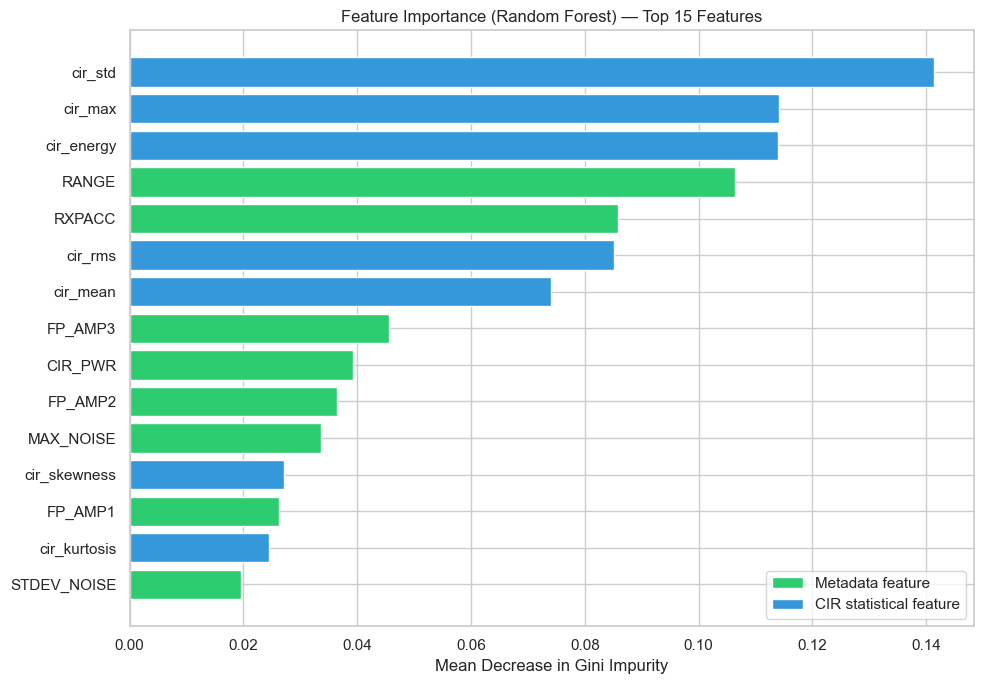


Interpretation: Features with higher importance contribute more to
separating LOS from NLOS. This confirms EDA correlation findings.


In [8]:
fig, ax = plt.subplots(figsize=(10, 7))
top15 = importance_df.head(15)
colors = ['#2ecc71' if 'cir' not in f else '#3498db' for f in top15['feature']]
ax.barh(top15['feature'][::-1], top15['importance'][::-1], color=colors[::-1])
ax.set_xlabel('Mean Decrease in Gini Impurity')
ax.set_title('Feature Importance (Random Forest) — Top 15 Features')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Metadata feature'),
    Patch(facecolor='#3498db', label='CIR statistical feature')
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig("results/data_prep/01_feature_importance_clf.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nInterpretation: Features with higher importance contribute more to")
print("separating LOS from NLOS. This confirms EDA correlation findings.")

## Feature Selection — Applying Importance Threshold

Based on the ranking above, **14 out of 19 features** pass the 2% importance threshold. Five features are dropped: `FP_IDX`, `STDEV_NOISE`, `FRAME_LEN`, `PREAM_LEN`, and `cir_peak_idx`.

The top three features are all CIR-derived statistics: **`cir_std`** ranks first at 14.1%, **`cir_max`** second at 11.4%, and **`cir_energy`** third at 11.4%. These capture the spread, peak amplitude, and total energy of the CIR waveform — all of which differ substantially between LOS (concentrated, high-amplitude pulse) and NLOS (dispersed, attenuated signal with multi-path energy spread across the waveform). **`RANGE`** ranks fourth at 10.6%, reflecting that the measured range itself correlates with LOS/NLOS condition since NLOS paths are systematically longer than the true direct distance. **`RXPACC`** ranks fifth at 8.6%, capturing how much energy the receiver accumulates over the CIR window, which differs between LOS (cleaner, concentrated signal) and NLOS (dispersed, attenuated signal).

The dropped features tell an informative story. `FP_IDX` — the sample index of the first detected path in the CIR — might be expected to separate LOS from NLOS, since the first path arrives earlier in LOS conditions. However, the amplitude and energy features already capture the same propagation information more directly and reliably, rendering the raw sample index redundant at this threshold. `STDEV_NOISE` and the frame/preamble length parameters (`FRAME_LEN`, `PREAM_LEN`) contribute less than 2% each, indicating that ambient noise floor variation and frame structure add little discriminative information beyond what the CIR statistics already provide.

All Task 1 classifiers train on this 14-feature set.

In [9]:
# ── Select features above importance threshold ────────────────────────────────
IMPORTANCE_THRESHOLD = 0.02  # drop features contributing < 2%

selected_clf_features = importance_df[
    importance_df['importance'] >= IMPORTANCE_THRESHOLD
]['feature'].tolist()
dropped_clf_features = [f for f in FEATURE_NAMES if f not in selected_clf_features]

print(f"Selected {len(selected_clf_features)} / {len(FEATURE_NAMES)} features "
      f"(importance >= {IMPORTANCE_THRESHOLD*100:.0f}%):")
for f in selected_clf_features:
    imp = importance_df.loc[importance_df['feature'] == f, 'importance'].values[0]
    print(f"  {f:<20s}  {imp:.4f}")
if dropped_clf_features:
    print(f"\nDropped {len(dropped_clf_features)} low-importance feature(s): {dropped_clf_features}")

# Build reduced feature matrices — used by ALL Task 1 classifiers
sel_clf_idx  = [list(FEATURE_NAMES).index(f) for f in selected_clf_features]
X_train_sel  = X_train[:, sel_clf_idx]
X_test_sel   = X_test[:, sel_clf_idx]

scaler_sel   = StandardScaler()
X_tr_sel_sc  = scaler_sel.fit_transform(X_train_sel)
X_te_sel_sc  = scaler_sel.transform(X_test_sel)

print(f"\nReduced shape — train: {X_train_sel.shape}, test: {X_test_sel.shape}")

Selected 14 / 19 features (importance >= 2%):
  cir_std               0.1413
  cir_max               0.1141
  cir_energy            0.1139
  RANGE                 0.1063
  RXPACC                0.0858
  cir_rms               0.0851
  cir_mean              0.0740
  FP_AMP3               0.0456
  CIR_PWR               0.0392
  FP_AMP2               0.0364
  MAX_NOISE             0.0336
  cir_skewness          0.0271
  FP_AMP1               0.0262
  cir_kurtosis          0.0244

Dropped 5 low-importance feature(s): ['FP_IDX', 'STDEV_NOISE', 'FRAME_LEN', 'PREAM_LEN', 'cir_peak_idx']

Reduced shape — train: (33600, 14), test: (8400, 14)


---
## Task 2 — Regression Feature Importance

A Random Forest is trained on the **full** regression feature set to rank importance. Models are retrained on the selected subset in `02_Regression.ipynb`.

In [10]:
# Train RF regressor on full feature set — used only for importance ranking.
# Results are NOT stored; models are retrained on selected features in 02_Regression.ipynb.
print("Computing regression feature importance (Random Forest, 200 trees)...")

rf_reg_imp = RandomForestRegressor(
    n_estimators=200, max_depth=None, min_samples_leaf=2,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_reg_imp.fit(X_reg_train, y_reg_train)
print("Done.")

Computing regression feature importance (Random Forest, 200 trees)...
Done.


## Feature Importance Analysis — Regression

The regression importance ranking differs markedly from classification. **`cir_max` dominates at 36.8%** — more than a third of the total importance comes from the peak CIR amplitude. This makes physical sense: signal amplitude decays with propagation distance (path loss), so a higher peak amplitude strongly signals a shorter measured range, while a lower amplitude is associated with longer or more obstructed paths. For regression, the amplitude directly encodes the distance information the model needs to predict.

**`cir_skewness` ranks second at 13.0%**, which is a notable result. The asymmetry of the CIR waveform carries distance-dependent information: at longer ranges, the CIR pulse becomes more spread-out and asymmetric as multi-path components accumulate over progressively longer time windows. The EDA correlation analysis is consistent with this — skewness increases with measured range.

**`cir_std` ranks third at 9.7%**, followed by `cir_mean` at 6.9%. These two features, together with `cir_max`, confirm that the overall scale and shape of the CIR waveform are the primary predictors of measured range in this dataset.

**`RXPACC` ranks fifth at only 4.7%**, a substantially weaker role than in classification (where it ranked fifth at 8.6%). For the binary LOS/NLOS classification task, receiver accumulation count is directly relevant — it captures a qualitative difference between concentrated and dispersed signals. For continuous range prediction, the absolute CIR amplitude features (`cir_max`, `cir_std`) carry the distance information more directly.

**`FP_IDX` scores just 1.4%** and gets dropped, despite being the direct time-of-flight sample index in the CIR — the fundamental quantity underlying UWB ranging. The likely explanation is that `FP_IDX` varies across a narrow range in this dataset (716–950 samples) relative to the variance in measured range (0–28 m), and the amplitude features capture the range information more continuously and reliably. This result is consistent with the classification task, where `FP_IDX` was also excluded by the importance threshold.

In [11]:
# ── Compute regression feature importance from the trained rf_reg_imp ─────────
reg_importance_df = pd.DataFrame({
    "feature"   : REG_FEATURE_NAMES,
    "importance": rf_reg_imp.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("Feature Importance — Random Forest Regressor (ranked by Mean Decrease in MSE):")
print(reg_importance_df.to_string(index=False))

Feature Importance — Random Forest Regressor (ranked by Mean Decrease in MSE):
     feature  importance
     cir_max    0.368262
cir_skewness    0.129556
     cir_std    0.096828
    cir_mean    0.069198
      RXPACC    0.047434
     CIR_PWR    0.035209
   MAX_NOISE    0.031499
     FP_AMP3    0.031331
     FP_AMP2    0.031215
     FP_AMP1    0.028033
cir_kurtosis    0.025422
   PREAM_LEN    0.025273
     cir_rms    0.017834
  cir_energy    0.017209
cir_peak_idx    0.016741
      FP_IDX    0.013882
 STDEV_NOISE    0.008845
   FRAME_LEN    0.006228


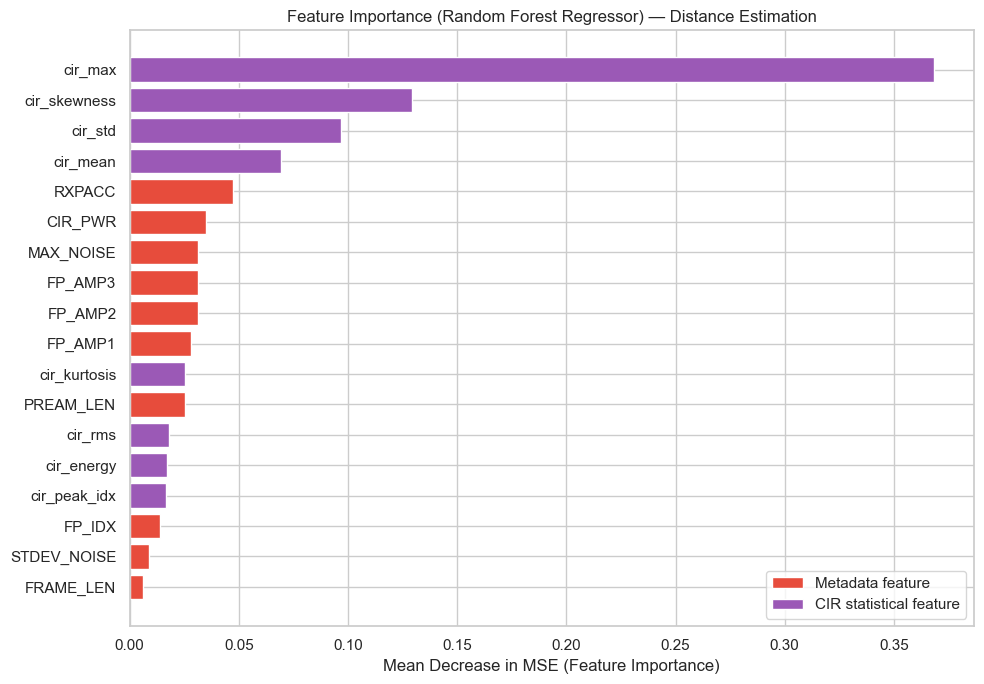

In [12]:
# ── Plot regression feature importance ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if 'cir' not in f else '#9b59b6' for f in reg_importance_df['feature']]
ax.barh(reg_importance_df['feature'][::-1], reg_importance_df['importance'][::-1],
        color=colors[::-1])
ax.set_xlabel('Mean Decrease in MSE (Feature Importance)')
ax.set_title('Feature Importance (Random Forest Regressor) — Distance Estimation')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Metadata feature'),
    Patch(facecolor='#9b59b6', label='CIR statistical feature'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig("results/data_prep/02_feature_importance_reg.png", dpi=120, bbox_inches="tight")
plt.show()

## Feature Selection — Applying Importance Threshold

**12 out of 18 features** pass the 2% threshold. Six are dropped: `FP_IDX`, `STDEV_NOISE`, `FRAME_LEN`, `cir_peak_idx`, `cir_energy`, and `cir_rms`.

More features are dropped here than in Task 1 (6 vs 5), reflecting a more concentrated importance distribution — `cir_max` alone accounts for 36.8% of total importance, leaving several other features below the threshold. Features that were retained for classification (`cir_energy`, `cir_rms`) are dropped for regression because, while they help distinguish LOS from NLOS signal patterns at a qualitative level, they do not independently explain additional variance in the continuous range target beyond what `cir_max`, `cir_std`, and `cir_mean` already provide.

The dropped `FP_IDX` remains the most counterintuitive result — it directly marks the first-path position in the CIR, which is the basis for time-of-flight ranging. However, the retained amplitude and statistical features collectively capture distance information well enough that the raw sample index adds little marginal value. All three regression models (RF, XGBoost, MLP) are trained on this 12-feature set in `02_Regression.ipynb`.

In [13]:
# ── Feature selection for regression ──────────────────────────────────────────
REG_IMPORTANCE_THRESHOLD = 0.02

selected_reg_features = reg_importance_df[
    reg_importance_df['importance'] >= REG_IMPORTANCE_THRESHOLD
]['feature'].tolist()
dropped_reg_features = [f for f in REG_FEATURE_NAMES if f not in selected_reg_features]

print(f"Selected {len(selected_reg_features)} / {len(REG_FEATURE_NAMES)} features "
      f"(importance >= {REG_IMPORTANCE_THRESHOLD*100:.0f}%):")
for f in selected_reg_features:
    imp = reg_importance_df.loc[reg_importance_df['feature'] == f, 'importance'].values[0]
    print(f"  {f:<20s}  {imp:.4f}")
if dropped_reg_features:
    print(f"\nDropped {len(dropped_reg_features)} low-importance feature(s): {dropped_reg_features}")

# Build reduced regression matrices and scaler
sel_reg_idx     = [REG_FEATURE_NAMES.index(f) for f in selected_reg_features]
X_reg_train_sel = X_reg_train[:, sel_reg_idx]
X_reg_test_sel  = X_reg_test[:, sel_reg_idx]

scaler_reg_sel      = StandardScaler()
X_reg_tr_sel_sc     = scaler_reg_sel.fit_transform(X_reg_train_sel)
X_reg_te_sel_sc     = scaler_reg_sel.transform(X_reg_test_sel)

print(f"\nReduced shape — train: {X_reg_train_sel.shape}, test: {X_reg_test_sel.shape}")

Selected 12 / 18 features (importance >= 2%):
  cir_max               0.3683
  cir_skewness          0.1296
  cir_std               0.0968
  cir_mean              0.0692
  RXPACC                0.0474
  CIR_PWR               0.0352
  MAX_NOISE             0.0315
  FP_AMP3               0.0313
  FP_AMP2               0.0312
  FP_AMP1               0.0280
  cir_kurtosis          0.0254
  PREAM_LEN             0.0253

Dropped 6 low-importance feature(s): ['FP_IDX', 'STDEV_NOISE', 'FRAME_LEN', 'cir_peak_idx', 'cir_energy', 'cir_rms']

Reduced shape — train: (33600, 12), test: (8400, 12)


---
## Save to Disk

All preprocessed arrays and fitted objects are persisted to `data/prepared/` so that `01_Classification.ipynb` and `02_Regression.ipynb` can run independently without re-executing any preprocessing steps.

Saving the **fitted scalers** with `joblib` is critical for correctness. Scalers must be fit exclusively on training data — fitting on the full dataset would constitute data leakage, as test-set statistics would influence the normalisation applied during model evaluation. By saving the scaler fitted on training data and loading it in downstream notebooks, we guarantee that the exact same transformation is applied consistently, and that the test set remains unseen during any fitting step.

The **CIR matrix** is saved separately (`cir_matrix.npy`) because it is a large array (42,000 × 1,016 float32 values) consumed only by the 1D CNN in Task 1, which operates directly on raw waveforms rather than the tabular feature set. Keeping it separate avoids inflating the `.npz` files used by the other models.

The **metadata JSON** records the selected feature names for both tasks. This makes it possible to trace any model output in Task 1 or Task 2 back to specific named features, which is important for interpretability and for verifying that downstream notebooks are loading the correct feature subsets.

In [14]:
Path("data/prepared").mkdir(parents=True, exist_ok=True)

# ── Task 1: classification arrays ─────────────────────────────────────────────
np.savez("data/prepared/task1_data.npz",
    X_train_sel = X_train_sel,
    X_test_sel  = X_test_sel,
    X_tr_sel_sc = X_tr_sel_sc,
    X_te_sel_sc = X_te_sel_sc,
    y_train     = y_train,
    y_test      = y_test,
    y_class     = y_class,
)
# CIR matrix saved separately (shared by CNN in Task 1 and path-2 in Task 2b)
np.save("data/prepared/cir_matrix.npy", cir_matrix)

# ── Task 2: regression arrays ─────────────────────────────────────────────────
np.savez("data/prepared/task2_data.npz",
    X_reg_train_sel = X_reg_train_sel,
    X_reg_test_sel  = X_reg_test_sel,
    X_reg_tr_sel_sc = X_reg_tr_sel_sc,
    X_reg_te_sel_sc = X_reg_te_sel_sc,
    y_reg_train     = y_reg_train,
    y_reg_test      = y_reg_test,
    X_reg           = X_reg,
    y_reg_full      = y_reg,
    fp_idx          = df_raw["FP_IDX"].values,
    nlos_labels     = df_raw["NLOS"].values,
    range_full      = df_raw["RANGE"].values,
)

# ── Scalers ────────────────────────────────────────────────────────────────────
joblib.dump(scaler_sel,     "data/prepared/scaler_clf.pkl")
joblib.dump(scaler_reg_sel, "data/prepared/scaler_reg_sel.pkl")

# ── Metadata ───────────────────────────────────────────────────────────────────
metadata = {
    "RANDOM_STATE"          : RANDOM_STATE,
    "selected_clf_features" : selected_clf_features,
    "selected_reg_features" : selected_reg_features,
    "FEATURE_NAMES"         : list(FEATURE_NAMES),
    "REG_FEATURE_NAMES"     : REG_FEATURE_NAMES,
}
with open("data/prepared/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved to data/prepared/")
print(f"  task1_data.npz  : {X_train_sel.shape[0]:,} train / {X_test_sel.shape[0]:,} test, {X_train_sel.shape[1]} clf features")
print(f"  task2_data.npz  : {X_reg_train_sel.shape[0]:,} train / {X_reg_test_sel.shape[0]:,} test, {X_reg_train_sel.shape[1]} reg features")
print(f"  cir_matrix.npy  : {cir_matrix.shape} (RXPACC-normalised)")

Saved to data/prepared/
  task1_data.npz  : 33,600 train / 8,400 test, 14 clf features
  task2_data.npz  : 33,600 train / 8,400 test, 12 reg features
  cir_matrix.npy  : (42000, 1016) (RXPACC-normalised)
